<a href="https://colab.research.google.com/github/LeonardooAlves/WM9B7-AIDL/blob/main/Week%202/4_RNN_Tutorial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Introduction to Recurrent Neural Networks (RNNs) in PyTorch

**MSc Applied Artificial Intelligence — AI & Deep Learning Module**

---

This notebook covers the fundamentals of RNNs through two practical examples, followed by a structured evaluation and exercises:

| Section | Task | RNN Pattern | What You'll Learn |
|---------|------|-------------|-------------------|
| **Example 1** | Next Word Prediction | Many-to-many | Data encoding, RNN forward pass, sequence memorisation |
| **Example 2** | Sentiment Classification | Many-to-one | Real-world data, embeddings, evaluation metrics |
| **Evaluation** | Model assessment | — | Accuracy, Precision, Recall, F1, Confusion Matrix |
| **Exercises** | Practice problems | — | Reinforce and extend your understanding |

### The Core RNN Equations

At every time step $t$, an RNN computes:

$$h_t = \tanh(W_{xh} \cdot x_t + W_{hh} \cdot h_{t-1} + b_h)$$
$$\hat{y}_t = W_{hy} \cdot h_t + b_y$$

The **hidden state** $h_t$ is the network's memory — it carries information from all previous time steps into the current one. The **same weights** are shared across every step.

> **Colab Tip:** Go to *Runtime → Change runtime type → T4 GPU* for faster training.

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

# Set random seeds for reproducibility — ensures everyone gets the same results
torch.manual_seed(42)
np.random.seed(42)

# Use GPU if available (much faster for matrix operations)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cpu


---
## Example 1: Next Word Prediction

We will train a simple RNN to learn a short sequence and predict the next word given the current word.

**The task:** Given the sentence *"recurrent neural networks are great for sequential data processing"*, the model should learn that after "recurrent" comes "neural", after "neural" comes "networks", and so on.

This is the simplest possible language modelling task — the model only needs to memorise one deterministic sequence.

### Step 1: Prepare the Data

Neural networks can't process raw text — they need numbers. We create a **vocabulary** that maps each unique word to an integer index.

In [2]:
# ============================================================
# DATA PREPARATION
# ============================================================

sentence = "recurrent neural networks are great for sequential data processing"
words = sentence.split()

# Build vocabulary: assign each unique word an integer index.
# Note: set() removes duplicates. In this sentence all 9 words are unique.
vocab = sorted(set(words))  # sorted() for deterministic ordering
word_to_ix = {w: i for i, w in enumerate(vocab)}  # word -> index
ix_to_word = {i: w for i, w in enumerate(vocab)}  # index -> word
vocab_size = len(vocab)

print("Vocabulary mapping:")
for word, idx in sorted(word_to_ix.items(), key=lambda x: x[1]):
    print(f"  '{word}' → {idx}")

# Create training pairs: (current_word, next_word)
# "recurrent" → "neural", "neural" → "networks", etc.
X = []  # inputs:  words[0], words[1], ..., words[n-2]
y = []  # targets: words[1], words[2], ..., words[n-1]
for i in range(len(words) - 1):
    X.append(word_to_ix[words[i]])
    y.append(word_to_ix[words[i+1]])

print(f"\nInput indices (X):  {X}")
print(f"Target indices (y): {y}")

# Show the mapping explicitly
print(f"\nTraining pairs:")
for xi, yi in zip(X, y):
    print(f"  '{ix_to_word[xi]}' → '{ix_to_word[yi]}'")

# Convert to PyTorch tensors
# X shape: (sequence_length, batch_size=1) — PyTorch RNNs with batch_first=False
# expect input as (seq_len, batch, features)
X_tensor = torch.tensor(X, dtype=torch.long).unsqueeze(1)  # (8, 1)
y_tensor = torch.tensor(y, dtype=torch.long)                # (8,)

print(f"\nX_tensor shape: {X_tensor.shape}  (seq_len, batch_size)")
print(f"y_tensor shape: {y_tensor.shape}  (seq_len,)")
print(f"Vocab size: {vocab_size}")

Vocabulary mapping:
  'are' → 0
  'data' → 1
  'for' → 2
  'great' → 3
  'networks' → 4
  'neural' → 5
  'processing' → 6
  'recurrent' → 7
  'sequential' → 8

Input indices (X):  [7, 5, 4, 0, 3, 2, 8, 1]
Target indices (y): [5, 4, 0, 3, 2, 8, 1, 6]

Training pairs:
  'recurrent' → 'neural'
  'neural' → 'networks'
  'networks' → 'are'
  'are' → 'great'
  'great' → 'for'
  'for' → 'sequential'
  'sequential' → 'data'
  'data' → 'processing'

X_tensor shape: torch.Size([8, 1])  (seq_len, batch_size)
y_tensor shape: torch.Size([8])  (seq_len,)
Vocab size: 9


### Step 2: Define the RNN Model

Our model has three layers:

```
Word index → Embedding (10-dim) → RNN (16 hidden units) → Linear → Logits (9 classes)
```

**Why an Embedding layer?** One-hot vectors are sparse and high-dimensional. The `nn.Embedding` layer learns a dense, lower-dimensional representation for each word (here 10 dimensions instead of 9). This becomes crucial when vocabularies are large (thousands of words).

In [3]:
# ============================================================
# MODEL DEFINITION
# ============================================================

class NextWordRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim):
        super(NextWordRNN, self).__init__()
        # Layer 1: Embedding — converts word indices to dense vectors
        # Input: integer index → Output: vector of size embed_dim
        self.embedding = nn.Embedding(vocab_size, embed_dim)

        # Layer 2: RNN — processes the sequence step by step
        # Input: (seq_len, batch, embed_dim) → Output: (seq_len, batch, hidden_dim)
        # batch_first=False means the sequence dimension comes first
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=False)

        # Layer 3: Fully connected — maps hidden state to vocabulary scores
        # Input: hidden_dim → Output: vocab_size (one score per word)
        self.fc = nn.Linear(hidden_dim, vocab_size)

    def forward(self, x, hidden):
        # x shape: (seq_len, batch_size) — integer indices
        embeds = self.embedding(x)        # → (seq_len, batch, embed_dim)
        out, hidden = self.rnn(embeds, hidden)  # → (seq_len, batch, hidden_dim)
        out = self.fc(out.squeeze(1))     # → (seq_len, vocab_size)
        return out, hidden


# Hyperparameters
embed_dim = 10   # dimension of word embeddings
hidden_dim = 16  # number of hidden units in the RNN

model = NextWordRNN(vocab_size, embed_dim, hidden_dim).to(device)

# CrossEntropyLoss: combines softmax + negative log-likelihood
# Appropriate for multi-class classification (predicting which of 9 words comes next)
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.01)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
print(f"Model architecture:\n{model}")
print(f"\nTotal trainable parameters: {total_params}")
print(f"  Embedding:  {vocab_size} × {embed_dim} = {vocab_size * embed_dim}")
print(f"  RNN:        W_ih({hidden_dim}×{embed_dim}) + W_hh({hidden_dim}×{hidden_dim}) + biases = {hidden_dim*embed_dim + hidden_dim*hidden_dim + 2*hidden_dim}")
print(f"  FC output:  {hidden_dim} × {vocab_size} + bias = {hidden_dim * vocab_size + vocab_size}")

Model architecture:
NextWordRNN(
  (embedding): Embedding(9, 10)
  (rnn): RNN(10, 16)
  (fc): Linear(in_features=16, out_features=9, bias=True)
)

Total trainable parameters: 691
  Embedding:  9 × 10 = 90
  RNN:        W_ih(16×10) + W_hh(16×16) + biases = 448
  FC output:  16 × 9 + bias = 153


### Step 3: Train the Model

Training loop: at each epoch we feed the **entire sequence** through the RNN, compute the loss between all predicted and target words, and update the weights via backpropagation through time (BPTT).

In [4]:
# ============================================================
# TRAINING LOOP
# ============================================================

epochs = 150
loss_history = []  # track loss for plotting

for epoch in range(epochs):
    model.train()

    # Reset hidden state at the start of each epoch.
    # We treat the sentence as a fresh sequence every time.
    hidden = None  # PyTorch will initialise to zeros

    optimizer.zero_grad()  # clear gradients from previous epoch

    # Forward pass: feed the full sequence
    output, hidden = model(X_tensor.to(device), hidden)
    # output shape: (8, 9) — 8 predictions, each over 9 words
    # y_tensor shape: (8,) — 8 ground-truth word indices
    loss = criterion(output, y_tensor.to(device))

    # Backward pass: compute gradients via BPTT
    loss.backward()
    optimizer.step()  # update all weights

    loss_history.append(loss.item())

    if (epoch+1) % 30 == 0:
        # Also compute accuracy at this checkpoint
        preds = output.argmax(dim=1)
        acc = (preds == y_tensor.to(device)).float().mean().item()
        print(f'Epoch [{epoch+1:3d}/{epochs}]  Loss: {loss.item():.4f}  Accuracy: {acc*100:.0f}%')

Epoch [ 30/150]  Loss: 0.0986  Accuracy: 100%
Epoch [ 60/150]  Loss: 0.0152  Accuracy: 100%
Epoch [ 90/150]  Loss: 0.0085  Accuracy: 100%
Epoch [120/150]  Loss: 0.0059  Accuracy: 100%
Epoch [150/150]  Loss: 0.0044  Accuracy: 100%


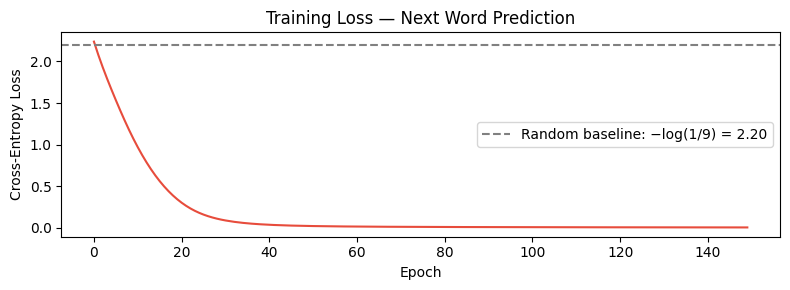

In [5]:
# ============================================================
# PLOT THE TRAINING LOSS
# ============================================================

plt.figure(figsize=(8, 3))
plt.plot(loss_history, color='#E74C3C', linewidth=1.5)
plt.axhline(y=-np.log(1/vocab_size), color='gray', linestyle='--',
            label=f'Random baseline: −log(1/{vocab_size}) = {-np.log(1/vocab_size):.2f}')
plt.xlabel('Epoch')
plt.ylabel('Cross-Entropy Loss')
plt.title('Training Loss — Next Word Prediction')
plt.legend()
plt.tight_layout()
plt.show()

### Step 4: Test the Predictions

We feed each word individually and check whether the model correctly predicts the next word. Since the model only saw one deterministic sequence, perfect accuracy means the model has **memorised** the sequence.

In [6]:
# ============================================================
# PREDICTION AND CONFIDENCE ANALYSIS
# ============================================================

def predict_next_word(input_word):
    """Predict the next word and return the full probability distribution."""
    model.eval()
    with torch.no_grad():
        ix = torch.tensor([[word_to_ix[input_word]]], dtype=torch.long).to(device)
        out, _ = model(ix, None)
        probs = F.softmax(out, dim=1).squeeze()  # convert logits → probabilities
        pred_ix = torch.argmax(probs).item()
        return ix_to_word[pred_ix], probs[pred_ix].item(), probs

print("--- Next Word Predictions ---\n")
print(f"{'Input':<14} {'Predicted':<14} {'Expected':<14} {'Confidence':>10}  {'Correct'}")
print("-" * 65)

correct = 0
for i, word in enumerate(words[:-1]):
    predicted, confidence, _ = predict_next_word(word)
    expected = words[i+1]
    match = predicted == expected
    if match: correct += 1
    symbol = "✓" if match else "✗"
    print(f"{word:<14} {predicted:<14} {expected:<14} {confidence:>9.1%}  {symbol}")

print(f"\nOverall accuracy: {correct}/{len(words)-1} = {correct/(len(words)-1)*100:.0f}%")

--- Next Word Predictions ---

Input          Predicted      Expected       Confidence  Correct
-----------------------------------------------------------------
recurrent      neural         neural             99.7%  ✓
neural         networks       networks           96.3%  ✓
networks       are            are                66.5%  ✓
are            great          great              97.8%  ✓
great          for            for                53.9%  ✓
for            sequential     sequential         82.1%  ✓
sequential     data           data               98.1%  ✓
data           processing     processing         94.6%  ✓

Overall accuracy: 8/8 = 100%


### Interpreting the Results

Let's look at the model's full output distribution for a single word — this reveals **how confident** the model is, not just its top prediction.

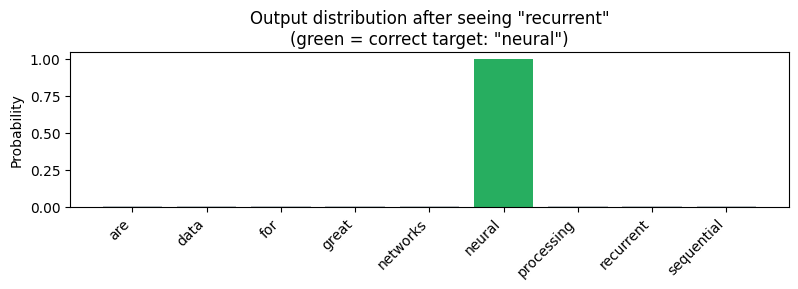

The model assigns 99.7% probability to the correct next word.
A random guess would give 11.1%.


In [7]:
# ============================================================
# VISUALISE THE OUTPUT DISTRIBUTION
# ============================================================

# Pick a word to inspect
inspect_word = "recurrent"
_, _, probs = predict_next_word(inspect_word)
probs_np = probs.cpu().numpy()

fig, ax = plt.subplots(figsize=(8, 3))
word_labels = [ix_to_word[i] for i in range(vocab_size)]
colours = ['#27AE60' if ix_to_word[i] == words[words.index(inspect_word)+1] else '#BDC3C7'
           for i in range(vocab_size)]
ax.bar(word_labels, probs_np, color=colours)
ax.set_ylabel('Probability')
ax.set_title(f'Output distribution after seeing "{inspect_word}"\n'
             f'(green = correct target: "{words[words.index(inspect_word)+1]}")')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print(f"The model assigns {probs_np.max()*100:.1f}% probability to the correct next word.")
print(f"A random guess would give {100/vocab_size:.1f}%.")

### 🔑 Example 1 — Key Takeaways

1. **The model memorised the sequence perfectly** — with only 9 unique words in a deterministic sequence, 150 epochs is more than enough. This is analogous to a student memorising a single flashcard.

2. **The hidden state carries context forward.** When we feed "recurrent" with `hidden=None`, the model relies purely on the word embedding. In a longer sequence, the accumulated hidden state would provide richer context.

3. **This is NOT generalisation.** The model cannot predict anything sensible for words it hasn't seen. Real language models are trained on millions of sentences so they learn general patterns rather than memorising individual sequences.

4. **Loss interpretation:** The initial loss (~2.2) is close to $-\log(1/9) \approx 2.20$, which is the cross-entropy for a uniform distribution over 9 classes. After training, the loss drops to ~0.005, meaning the model is nearly 100% certain of the correct answer at every step.

---

## Example 2: Sentiment Classification (IMDB)

We move to a **real-world task**: classifying movie reviews as **positive** (1) or **negative** (0).

This is a **many-to-one** architecture — the RNN reads an entire sequence of words and produces a single classification at the end.

```
Word indices → Embedding (32-dim) → RNN (64 hidden) → Final hidden state → Linear → Sigmoid → [0,1]
```

### Key Differences from Example 1

| Aspect | Example 1 | Example 2 |
|--------|-----------|----------|
| Task | Predict next word | Classify sentiment |
| Pattern | Many-to-many | Many-to-one |
| Vocab | 9 words | 2,000 words |
| Data | 1 sentence | 500 reviews |
| Output | Softmax over vocab | Sigmoid (binary) |

In [8]:
!pip install datasets -q

### Step 1: Load and Prepare the Data

We load 500 training reviews and 200 test reviews from the IMDB dataset. We build a vocabulary of the 2,000 most common words, and represent each review as a fixed-length sequence of word indices (padded or truncated to 100 tokens).

In [10]:
from datasets import load_dataset
from torch.utils.data import DataLoader, Dataset
import re
from collections import Counter

# ============================================================
# LOAD DATA — small slices for fast training on Colab
# ============================================================

# Training set: 500 reviews; Test set: 200 reviews (separate, unseen data)
train_dataset_hf = load_dataset('imdb', split='train').shuffle(seed=42).select(range(500))
test_dataset_hf  = load_dataset('imdb', split='test').shuffle(seed=42).select(range(200))

# Quick look at the data
print(f"Training samples: {len(train_dataset_hf)}")
print(f"Test samples:     {len(test_dataset_hf)}")
print(f"Label mapping:    0 = Negative, 1 = Positive")
print(f"\nExample review (first 200 chars):")
print(f"  Text:  '{train_dataset_hf[0]['text'][:200]}...'")
print(f"  Label: {train_dataset_hf[0]['label']} ({'Positive' if train_dataset_hf[0]['label'] == 1 else 'Negative'})")

# Check class balance
train_labels = [item['label'] for item in train_dataset_hf]
print(f"\nTraining set class balance: {sum(train_labels)} positive, {len(train_labels)-sum(train_labels)} negative")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

plain_text/train-00000-of-00001.parquet:   0%|          | 0.00/21.0M [00:00<?, ?B/s]

plain_text/test-00000-of-00001.parquet:   0%|          | 0.00/20.5M [00:00<?, ?B/s]

plain_text/unsupervised-00000-of-00001.p(…):   0%|          | 0.00/42.0M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/25000 [00:00<?, ? examples/s]

Generating unsupervised split:   0%|          | 0/50000 [00:00<?, ? examples/s]

Training samples: 500
Test samples:     200
Label mapping:    0 = Negative, 1 = Positive

Example review (first 200 chars):
  Text:  'There is no relation at all between Fortier and Profiler but the fact that both are police series about violent crimes. Profiler looks crispy, Fortier looks classic. Profiler plots are quite simple. F...'
  Label: 1 (Positive)

Training set class balance: 246 positive, 254 negative


In [11]:
# ============================================================
# TOKENISATION AND VOCABULARY
# ============================================================

def tokenize(text):
    """Simple whitespace tokenizer: lowercase, remove punctuation, split."""
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)  # keep only letters and spaces
    return text.split()

# Count word frequencies across all training reviews
all_words = []
for item in train_dataset_hf:
    all_words.extend(tokenize(item['text']))

vocab_counts = Counter(all_words)
print(f"Total tokens in training set: {len(all_words):,}")
print(f"Unique words: {len(vocab_counts):,}")
print(f"Top 10 words: {vocab_counts.most_common(10)}")

# Build vocabulary: <PAD> for padding, <UNK> for out-of-vocabulary words
# We keep the top 2000 words — words outside this will map to <UNK>
MAX_VOCAB = 2000
vocab2 = ['<PAD>', '<UNK>'] + [w for w, c in vocab_counts.most_common(MAX_VOCAB)]
word2idx = {w: i for i, w in enumerate(vocab2)}
UNK_IDX = word2idx['<UNK>']  # = 1
PAD_IDX = word2idx['<PAD>']  # = 0

print(f"\nFinal vocabulary size (incl. <PAD>, <UNK>): {len(vocab2)}")

# What fraction of tokens are covered?
covered = sum(c for w, c in vocab_counts.most_common(MAX_VOCAB))
print(f"Vocabulary coverage: {covered/len(all_words)*100:.1f}% of all tokens")

Total tokens in training set: 114,341
Unique words: 13,471
Top 10 words: [('the', 6518), ('a', 3190), ('and', 3171), ('of', 2893), ('to', 2713), ('is', 2178), ('in', 1757), ('it', 1622), ('this', 1576), ('i', 1491)]

Final vocabulary size (incl. <PAD>, <UNK>): 2002
Vocabulary coverage: 83.9% of all tokens


In [12]:
# ============================================================
# PYTORCH DATASET — fixed-length sequences with padding
# ============================================================

MAX_LEN = 100  # truncate long reviews, pad short ones

class IMDBDataset(Dataset):
    """
    Converts HuggingFace IMDB items into (token_indices, label) tensors.

    Each review is:
      1. Tokenised (lowercased, punctuation removed)
      2. Truncated to max_len tokens
      3. Padded with <PAD> (index 0) if shorter than max_len
      4. Words not in vocab are replaced with <UNK> (index 1)
    """
    def __init__(self, hf_dataset, max_len=MAX_LEN):
        self.data = []
        for item in hf_dataset:
            tokens = tokenize(item['text'])
            # Map tokens to indices; unknown words → UNK_IDX
            indices = [word2idx.get(w, UNK_IDX) for w in tokens[:max_len]]
            # Pad short sequences to fixed length
            if len(indices) < max_len:
                indices += [PAD_IDX] * (max_len - len(indices))
            self.data.append((
                torch.tensor(indices, dtype=torch.long),
                torch.tensor(item['label'], dtype=torch.float32)
            ))

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


# Create datasets and data loaders
train_data = IMDBDataset(train_dataset_hf)
test_data  = IMDBDataset(test_dataset_hf)

BATCH_SIZE = 32
train_loader = DataLoader(train_data, batch_size=BATCH_SIZE, shuffle=True)
test_loader  = DataLoader(test_data,  batch_size=BATCH_SIZE, shuffle=False)

print(f"Training samples: {len(train_data)} → {len(train_loader)} batches")
print(f"Test samples:     {len(test_data)} → {len(test_loader)} batches")

Training samples: 500 → 16 batches
Test samples:     200 → 7 batches


### Step 2: Define the Sentiment RNN

This is a **many-to-one** model: it reads all tokens, then uses only the **final hidden state** to classify the entire review.

```
"this movie was great" → Embed → RNN(h₁→h₂→h₃→h₄) → h₄ → Linear → Sigmoid → 0.87 (Positive)
```

In [13]:
# ============================================================
# MODEL DEFINITION
# ============================================================

class SentimentRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(SentimentRNN, self).__init__()

        # Embedding: learns dense representations for each word
        # padding_idx=PAD_IDX ensures the <PAD> token always maps to a zero vector
        # (so padding doesn't contribute to the hidden state)
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=PAD_IDX)

        # RNN: processes the embedded sequence step by step
        # batch_first=True means input shape is (batch_size, seq_len, embed_dim)
        self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)

        # Classifier: maps the final hidden state to a single output score
        self.fc = nn.Linear(hidden_dim, output_dim)

        # Sigmoid: squashes the score to [0, 1] for binary classification
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        # x shape: (batch_size, seq_len) — word indices
        embeds = self.embedding(x)        # → (batch, seq_len, embed_dim)
        out, hidden = self.rnn(embeds)    # hidden: (1, batch, hidden_dim)

        # We use the FINAL hidden state as the review's representation
        # This is the many-to-one pattern: the hidden state at the last step
        # should encode the "meaning" of the entire review
        final_hidden = hidden.squeeze(0)  # → (batch, hidden_dim)

        out = self.fc(final_hidden)       # → (batch, 1)
        return self.sigmoid(out)          # → (batch, 1) in range [0, 1]


# Hyperparameters
EMBED_DIM  = 32   # embedding dimension
HIDDEN_DIM = 64   # RNN hidden state size

model2 = SentimentRNN(len(vocab2), EMBED_DIM, HIDDEN_DIM, output_dim=1).to(device)

# BCELoss: Binary Cross Entropy — appropriate for sigmoid output + binary labels
criterion2 = nn.BCELoss()
optimizer2 = optim.Adam(model2.parameters(), lr=0.005)

print(model2)
total_params2 = sum(p.numel() for p in model2.parameters())
print(f"\nTotal trainable parameters: {total_params2:,}")

SentimentRNN(
  (embedding): Embedding(2002, 32, padding_idx=0)
  (rnn): RNN(32, 64, batch_first=True)
  (fc): Linear(in_features=64, out_features=1, bias=True)
  (sigmoid): Sigmoid()
)

Total trainable parameters: 70,401


### Step 3: Train the Sentiment Model

We train for 5 epochs and track **both loss and accuracy** on the training set each epoch. We also evaluate on the **held-out test set** at each epoch to monitor generalisation.

In [14]:
# ============================================================
# TRAINING LOOP — with training AND test monitoring
# ============================================================

def compute_accuracy(model, loader):
    """Compute accuracy on a dataset."""
    model.eval()
    correct, total = 0, 0
    with torch.no_grad():
        for inputs, labels in loader:
            inputs, labels = inputs.to(device), labels.to(device)
            preds = model(inputs).squeeze(1)
            predicted = (preds >= 0.5).float()
            correct += (predicted == labels).sum().item()
            total += labels.size(0)
    return correct / total


epochs2 = 10
train_losses = []
train_accs = []
test_accs  = []

for epoch in range(epochs2):
    model2.train()
    total_loss = 0
    train_correct, train_total = 0, 0

    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer2.zero_grad()  # clear previous gradients

        predictions = model2(inputs).squeeze(1)  # (batch,)
        loss = criterion2(predictions, labels)

        loss.backward()         # compute gradients via BPTT
        optimizer2.step()       # update weights

        total_loss += loss.item()
        # Track training accuracy within the epoch
        predicted = (predictions >= 0.5).float()
        train_correct += (predicted == labels).sum().item()
        train_total += labels.size(0)

    avg_loss  = total_loss / len(train_loader)
    train_acc = train_correct / train_total
    test_acc  = compute_accuracy(model2, test_loader)

    train_losses.append(avg_loss)
    train_accs.append(train_acc)
    test_accs.append(test_acc)

    print(f'Epoch [{epoch+1:2d}/{epochs2}]  '
          f'Loss: {avg_loss:.4f}  '
          f'Train Acc: {train_acc*100:5.1f}%  '
          f'Test Acc: {test_acc*100:5.1f}%')

Epoch [ 1/10]  Loss: 0.7131  Train Acc:  47.0%  Test Acc:  48.0%
Epoch [ 2/10]  Loss: 0.6558  Train Acc:  60.6%  Test Acc:  53.5%
Epoch [ 3/10]  Loss: 0.6054  Train Acc:  67.6%  Test Acc:  52.0%
Epoch [ 4/10]  Loss: 0.5546  Train Acc:  74.6%  Test Acc:  51.0%
Epoch [ 5/10]  Loss: 0.5274  Train Acc:  75.4%  Test Acc:  49.5%
Epoch [ 6/10]  Loss: 0.5837  Train Acc:  70.4%  Test Acc:  49.5%
Epoch [ 7/10]  Loss: 0.5692  Train Acc:  70.4%  Test Acc:  51.0%
Epoch [ 8/10]  Loss: 0.5508  Train Acc:  70.8%  Test Acc:  53.0%
Epoch [ 9/10]  Loss: 0.5546  Train Acc:  70.6%  Test Acc:  48.0%
Epoch [10/10]  Loss: 0.5321  Train Acc:  72.2%  Test Acc:  56.0%


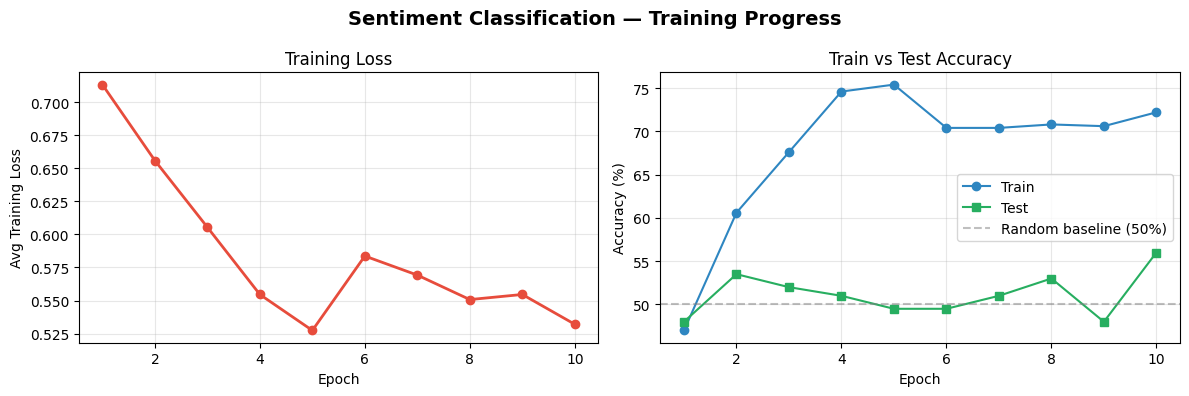

In [15]:
# ============================================================
# PLOT TRAINING CURVES
# ============================================================

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

# Loss curve
ax1.plot(range(1, epochs2+1), train_losses, 'o-', color='#E74C3C', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Avg Training Loss')
ax1.set_title('Training Loss')
ax1.grid(alpha=0.3)

# Accuracy curves — train vs test
ax2.plot(range(1, epochs2+1), [a*100 for a in train_accs], 'o-', color='#2E86C1', label='Train')
ax2.plot(range(1, epochs2+1), [a*100 for a in test_accs], 's-', color='#27AE60', label='Test')
ax2.axhline(y=50, color='gray', linestyle='--', alpha=0.5, label='Random baseline (50%)')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Train vs Test Accuracy')
ax2.legend()
ax2.grid(alpha=0.3)

plt.suptitle('Sentiment Classification — Training Progress', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Step 4: Test with Custom Sentences

In [16]:
# ============================================================
# INTERACTIVE PREDICTION
# ============================================================

def predict_sentiment(review_text, verbose=True):
    """Predict sentiment for a single review. Returns score and label."""
    model2.eval()
    with torch.no_grad():
        tokens = tokenize(review_text)

        # Check how many tokens are in-vocabulary vs <UNK>
        indices = [word2idx.get(w, UNK_IDX) for w in tokens]
        n_unk = sum(1 for idx in indices if idx == UNK_IDX)

        # Pad to MAX_LEN (same as training)
        if len(indices) < MAX_LEN:
            indices += [PAD_IDX] * (MAX_LEN - len(indices))
        else:
            indices = indices[:MAX_LEN]

        tensor = torch.tensor(indices, dtype=torch.long).unsqueeze(0).to(device)
        score = model2(tensor).item()
        label = "Positive" if score >= 0.5 else "Negative"

        if verbose:
            emoji = "😊" if score >= 0.5 else "😞"
            print(f'Review:    "{review_text}"')
            print(f'Tokens:    {len(tokens)} words ({n_unk} unknown/OOV)')
            print(f'Sentiment: {label} {emoji}  (score: {score:.4f})')
            print()

        return score, label


print("=" * 70)
print("SENTIMENT PREDICTIONS")
print("=" * 70 + "\n")

predict_sentiment("This movie was fantastic and beautifully directed.")
predict_sentiment("Terrible acting and a completely boring plot.")
predict_sentiment("The film had some good moments but overall it was mediocre.")
predict_sentiment("One of the best movies I have ever seen in my life.")
predict_sentiment("An absolute waste of time. Do not watch this.")

SENTIMENT PREDICTIONS

Review:    "This movie was fantastic and beautifully directed."
Tokens:    7 words (0 unknown/OOV)
Sentiment: Positive 😊  (score: 0.6033)

Review:    "Terrible acting and a completely boring plot."
Tokens:    7 words (0 unknown/OOV)
Sentiment: Negative 😞  (score: 0.4508)

Review:    "The film had some good moments but overall it was mediocre."
Tokens:    11 words (1 unknown/OOV)
Sentiment: Negative 😞  (score: 0.4853)

Review:    "One of the best movies I have ever seen in my life."
Tokens:    12 words (0 unknown/OOV)
Sentiment: Positive 😊  (score: 0.5229)

Review:    "An absolute waste of time. Do not watch this."
Tokens:    9 words (0 unknown/OOV)
Sentiment: Positive 😊  (score: 0.5141)



(0.5141396522521973, 'Positive')

### Interpreting the Results — Why Predictions May Be Poor

If you notice the model predicting Negative for everything (or giving very low scores to clearly positive reviews), this is **expected behaviour** for this setup, and it's instructive to understand why:

1. **Tiny training set (500 reviews):** Deep learning models typically need thousands to tens of thousands of examples. With 500 reviews, the model has very limited exposure to the patterns that distinguish positive from negative sentiment.

2. **Small vocabulary (2,000 words):** Many important sentiment words in the test reviews may map to `<UNK>`, losing critical information. Check the `n_unk` count in the output above.

3. **Vanilla RNN (not LSTM):** Plain RNNs suffer from the **vanishing gradient problem** — gradients shrink exponentially as they flow backward through time. With `max_len=100`, information from the beginning of a review may be completely lost by the time the RNN reaches the end.

4. **Only 5–10 epochs:** The model may need more training to converge on such limited data.

5. **No padding awareness:** Our vanilla RNN processes all 100 positions (including padding tokens), which can dilute the signal from actual content words.

**These are exactly the limitations you'll address in the exercises below.**

---
## Model Evaluation and Metrics

Accuracy alone is not enough to assess a classifier. We compute a full evaluation using:

| Metric | What it Measures |
|--------|------------------|
| **Accuracy** | Overall correctness |
| **Precision** | Of those predicted positive, how many truly are? |
| **Recall** | Of all actual positives, how many were caught? |
| **F1 Score** | Harmonic mean of Precision and Recall — balances both |
| **Confusion Matrix** | Full breakdown of TP, FP, TN, FN |

In [17]:
# ============================================================
# COMPREHENSIVE EVALUATION ON THE TEST SET
# ============================================================

from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report)

def evaluate_model(model, loader):
    """Collect all predictions and labels from a dataloader."""
    model.eval()
    all_scores = []
    all_labels = []
    with torch.no_grad():
        for inputs, labels in loader:
            inputs = inputs.to(device)
            scores = model(inputs).squeeze(1).cpu()
            all_scores.extend(scores.tolist())
            all_labels.extend(labels.tolist())
    return np.array(all_scores), np.array(all_labels)


# Get predictions on the test set
test_scores, test_labels = evaluate_model(model2, test_loader)
test_preds = (test_scores >= 0.5).astype(int)

# ── Classification Report ────────────────────────────────────
print("=" * 55)
print("CLASSIFICATION REPORT — Test Set")
print("=" * 55)
# labels=[0,1] ensures both classes always appear in the report, even if
# the model predicts only one class (a common failure mode with tiny data).
print(classification_report(test_labels, test_preds,
                            labels=[0, 1],
                            target_names=['Negative', 'Positive'],
                            digits=3, zero_division=0))

# Check if the model is predicting a single class for everything
unique_preds = np.unique(test_preds)
if len(unique_preds) == 1:
    print(f"  WARNING: The model predicts class {int(unique_preds[0])} "
          f"({'Positive' if unique_preds[0]==1 else 'Negative'}) for ALL test samples.")
    print(f"   This is a common failure mode when training data is too small ")
    print(f"   or the model hasn't learned to separate the classes.")
    print(f"   See the exercises below to address this (more data, LSTM, etc.).")

CLASSIFICATION REPORT — Test Set
              precision    recall  f1-score   support

    Negative      0.614     0.413     0.494       104
    Positive      0.531     0.719     0.611        96

    accuracy                          0.560       200
   macro avg      0.573     0.566     0.552       200
weighted avg      0.574     0.560     0.550       200



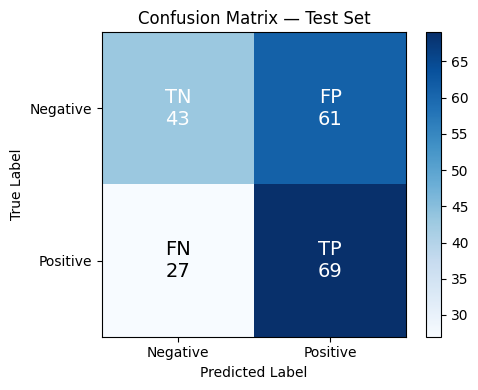

True Negatives  (TN):  43 — correctly identified as negative
False Positives (FP):  61 — negative reviews wrongly called positive
False Negatives (FN):  27 — positive reviews wrongly called negative
True Positives  (TP):  69 — correctly identified as positive


In [18]:
# ============================================================
# CONFUSION MATRIX — visualised as a heatmap
# ============================================================

cm = confusion_matrix(test_labels, test_preds, labels=[0, 1])

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap='Blues')

# Labels and annotations
ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Negative', 'Positive'])
ax.set_yticklabels(['Negative', 'Positive'])
ax.set_xlabel('Predicted Label')
ax.set_ylabel('True Label')
ax.set_title('Confusion Matrix — Test Set')

# Annotate each cell with its count
labels_text = [['TN', 'FP'], ['FN', 'TP']]
for i in range(2):
    for j in range(2):
        colour = 'white' if cm[i, j] > cm.max()/2 else 'black'
        ax.text(j, i, f"{labels_text[i][j]}\n{cm[i,j]}",
                ha='center', va='center', color=colour, fontsize=14)

plt.colorbar(im, fraction=0.046)
plt.tight_layout()
plt.show()

# Print interpretation
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives  (TN): {tn:3d} — correctly identified as negative")
print(f"False Positives (FP): {fp:3d} — negative reviews wrongly called positive")
print(f"False Negatives (FN): {fn:3d} — positive reviews wrongly called negative")
print(f"True Positives  (TP): {tp:3d} — correctly identified as positive")

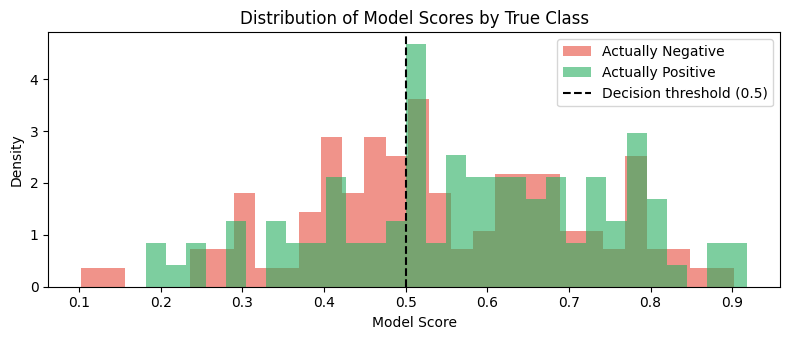

Interpretation:
• If both distributions cluster on the SAME side of 0.5, the model
  cannot distinguish positive from negative reviews.
• A well-trained model would show red (negative) clustered near 0
  and green (positive) clustered near 1, with minimal overlap.


In [19]:
# ============================================================
# SCORE DISTRIBUTION — are the model's scores well-separated?
# ============================================================

fig, ax = plt.subplots(figsize=(8, 3.5))

# Plot score distributions for each class
neg_scores = test_scores[test_labels == 0]
pos_scores = test_scores[test_labels == 1]

ax.hist(neg_scores, bins=30, alpha=0.6, color='#E74C3C', label='Actually Negative', density=True)
ax.hist(pos_scores, bins=30, alpha=0.6, color='#27AE60', label='Actually Positive', density=True)
ax.axvline(x=0.5, color='black', linestyle='--', label='Decision threshold (0.5)')
ax.set_xlabel('Model Score')
ax.set_ylabel('Density')
ax.set_title('Distribution of Model Scores by True Class')
ax.legend()
plt.tight_layout()
plt.show()

print("Interpretation:")
print("• If both distributions cluster on the SAME side of 0.5, the model")
print("  cannot distinguish positive from negative reviews.")
print("• A well-trained model would show red (negative) clustered near 0")
print("  and green (positive) clustered near 1, with minimal overlap.")

### Interpreting the Evaluation

**What to look for:**

- **Accuracy near 50%** means the model is no better than a coin flip — the most common failure mode for this small setup.
- **High precision but low recall** (or vice versa) reveals a biased model — e.g., it always predicts "negative" and happens to be right for the negative class.
- **Score distribution overlap:** If both classes produce similar score distributions, the model's internal representations aren't capturing sentiment. The RNN's 64-dimensional hidden state is simply not learning a useful distinction.

**Why is this happening?** Go back to the list under *"Why Predictions May Be Poor"* above. Each issue (small data, small vocab, vanilla RNN, few epochs) compounds the others.

---

## Key Takeaways — Both Examples

1. **Memorisation ≠ Generalisation.** Example 1 achieves 100% accuracy by memorising one sequence. Example 2 shows that real-world generalisation is much harder.

2. **Data quantity matters enormously.** 500 reviews is far too few for a deep learning model to learn robust sentiment patterns.

3. **Vanilla RNNs struggle with long sequences** due to vanishing gradients. LSTMs and GRUs were designed to solve this (by introducing gates that control information flow).

4. **Evaluation must go beyond accuracy.** Precision, Recall, F1, and the confusion matrix give a much richer picture of model behaviour. A model that always predicts "negative" has 50% accuracy on a balanced dataset but 0% recall on the positive class.

5. **The score distribution plot is diagnostic.** It shows whether the model has actually learned to separate the classes internally, even if the accuracy numbers look acceptable.

---

# Exercises

The following exercises progress from foundational modifications to more open-ended challenges. They are designed so that each one addresses a specific limitation of the models above.

## Exercise 1 — Sequence Generation (Easy)

In Example 1, `predict_next_word()` predicts one step at a time. But we can **chain** predictions: feed the output of one step as the input to the next.

**Task:** Write a function `generate_sequence(start_word, num_steps)` that:
1. Takes a starting word (e.g., `"recurrent"`)
2. Predicts the next word
3. Feeds that predicted word back as input
4. Repeats for `num_steps` iterations
5. Returns the full generated sequence as a string

**Test it:** Call `generate_sequence("recurrent", 8)` — does it reproduce the original sentence?

**Think about:** What happens if the model has only seen each word once? Can it ever generate anything *other* than the memorised sequence?

In [20]:
# ============================================================
# EXERCISE 1 — Your code here
# ============================================================

def generate_sequence(start_word, num_steps):
    """Generate a sequence by chaining predictions."""
    # TODO:
    # 1. Start with the given word
    # 2. In a loop: predict next word, append it, use it as next input
    # 3. Maintain hidden state across steps (don't reset it!)
    # 4. Return the full sequence as a list of words
    pass

# Test it
# result = generate_sequence("recurrent", 8)
# print(" ".join(result))

## Exercise 2 — Longer Sentence and Confusion Analysis (Easy)

Our 9-word sentence is trivially easy because each word appears exactly once — there is no ambiguity.

**Task:**
1. Replace the training sentence with: *"the cat sat on the mat and the dog sat on the rug"* (note: "the", "sat", and "on" each appear multiple times)
2. Retrain the `NextWordRNN` model for 300 epochs
3. Test predictions for **every** occurrence of "the" — what does the model predict?

**Questions to answer:**
- Can the model predict different next words for "the" depending on position? Why or why not?
- What is the fundamental limitation of feeding one word at a time without hidden state context?

In [21]:
# ============================================================
# EXERCISE 2 — Your code here
# ============================================================

# TODO:
# 1. New sentence with repeated words
# 2. Rebuild vocabulary and training pairs
# 3. Train for 300 epochs
# 4. Test: what does the model predict after "the"?



## Exercise 3 — Upgrade to LSTM (Medium)

The vanilla RNN in Example 2 likely underperforms due to the **vanishing gradient problem** — gradients shrink exponentially over long sequences.

**LSTMs** solve this with gating mechanisms (forget gate, input gate, output gate) that control information flow.

**Task:**
1. Create a new class `SentimentLSTM` that replaces `nn.RNN` with `nn.LSTM`
2. Keep all other hyperparameters identical
3. Train for the same number of epochs
4. Compare: accuracy, F1 score, and the score distribution plot

**Hint:** `nn.LSTM` returns `(output, (h_n, c_n))` instead of `(output, h_n)`. The cell state `c_n` is LSTM-specific — you don't need to use it for classification; just use `h_n` as before.

**Questions:**
- Does the LSTM improve test accuracy?
- Is the score distribution better separated?

In [22]:
# ============================================================
# EXERCISE 3 — Your code here
# ============================================================

class SentimentLSTM(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(SentimentLSTM, self).__init__()
        # TODO: Same structure but replace nn.RNN with nn.LSTM
        pass

    def forward(self, x):
        # TODO: Note that LSTM returns (output, (h_n, c_n))
        pass

# TODO: Train and evaluate, then compare metrics and plots



## Exercise 4 — More Data, Bigger Vocabulary (Medium)

One of the main limitations above is the tiny training set (500 reviews) and small vocabulary (2,000 words).

**Task:**
1. Increase the training data to **5,000 reviews** (change `train[:500]` to `train[:5000]`)
2. Increase the vocabulary to **10,000 words**
3. Increase `MAX_LEN` to **200**
4. Train the original `SentimentRNN` for 10 epochs on this larger dataset
5. Evaluate using the classification report and confusion matrix

**Questions:**
- How much does accuracy improve compared to the 500-sample model?
- Which had more impact: more data or bigger vocabulary? (Try them separately to find out.)
- Does the score distribution look better separated now?

In [23]:
# ============================================================
# EXERCISE 4 — Your code here
# ============================================================

# TODO:
# 1. Reload with more data: load_dataset('imdb', split='train[:5000]')
# 2. Rebuild vocabulary with top 10,000 words
# 3. Rebuild datasets with MAX_LEN=200
# 4. Train and evaluate



## Exercise 5 — Hyperparameter Experiment (Medium)

Run a systematic comparison of hyperparameter choices.

**Task:** For each configuration below, train the `SentimentRNN` for 10 epochs and record the final test accuracy and F1 score:

| Config | `embed_dim` | `hidden_dim` | `lr` |
|--------|:-----------:|:------------:|:----:|
| A (baseline) | 32 | 64 | 0.005 |
| B | 64 | 64 | 0.005 |
| C | 32 | 128 | 0.005 |
| D | 32 | 64 | 0.001 |
| E | 64 | 128 | 0.001 |

Plot the test accuracy for all five configurations on a single chart.

**Questions:**
- Which hyperparameter has the largest effect?
- Does a larger model always help, or can it hurt? (Think about overfitting on 500 samples.)

In [24]:
# ============================================================
# EXERCISE 5 — Your code here
# ============================================================

configs = [
    {'name': 'A (baseline)', 'embed_dim': 32, 'hidden_dim': 64,  'lr': 0.005},
    {'name': 'B',            'embed_dim': 64, 'hidden_dim': 64,  'lr': 0.005},
    {'name': 'C',            'embed_dim': 32, 'hidden_dim': 128, 'lr': 0.005},
    {'name': 'D',            'embed_dim': 32, 'hidden_dim': 64,  'lr': 0.001},
    {'name': 'E',            'embed_dim': 64, 'hidden_dim': 128, 'lr': 0.001},
]

# TODO:
# For each config: create model, train, record test_accs per epoch
# Plot all on one graph



## Exercise 6 — Gradient Clipping and the Exploding Gradient Problem (Hard)

RNNs are prone to **exploding gradients** where gradient magnitudes grow exponentially during BPTT, causing unstable training (loss spikes or NaN values).

**Gradient clipping** caps the gradient norm to prevent this.

**Task:**
1. Add gradient norm tracking to the training loop: after `loss.backward()`, compute `torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm)` and record the returned gradient norm.
2. Train the `SentimentRNN` with three settings:
   - No clipping (`max_norm=float('inf')`)
   - Aggressive clipping (`max_norm=1.0`)
   - Standard clipping (`max_norm=5.0`)
3. Plot the gradient norm over training steps for all three

**Questions:**
- Do you observe gradient spikes without clipping?
- Does clipping help or hurt final accuracy?

*Reference: This connects to BPTT and the vanishing/exploding gradient discussion in the lecture slides.*

In [25]:
# ============================================================
# EXERCISE 6 — Your code here
# ============================================================

# Hint: After loss.backward(), before optimizer.step():
# grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
# This returns the ORIGINAL norm (before clipping) so you can track it.

# TODO: Implement the comparison



## Exercise 7 — Bidirectional RNN for Sentiment (Hard)

A unidirectional RNN only sees context from the left. A **bidirectional** RNN processes the sequence in both directions and concatenates the two final hidden states.

**Task:**
1. Create `SentimentBiRNN` using `nn.RNN(..., bidirectional=True)`
2. Handle the output correctly: the hidden state shape changes from `(1, batch, hidden)` to `(2, batch, hidden)` — concatenate forward and backward states to get `(batch, 2*hidden)`
3. Adjust the `nn.Linear` layer input size accordingly
4. Compare metrics against the unidirectional model

**Questions:**
- Does bidirectionality help for sentiment classification? Why might it?
- How does the parameter count change?

In [26]:
# ============================================================
# EXERCISE 7 — Your code here
# ============================================================

class SentimentBiRNN(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_dim, output_dim):
        super(SentimentBiRNN, self).__init__()
        # TODO:
        # - Embedding (same as before)
        # - nn.RNN(..., bidirectional=True)
        # - nn.Linear(hidden_dim * 2, output_dim)  ← note the *2
        pass

    def forward(self, x):
        # TODO:
        # hidden shape is now (2, batch, hidden_dim)
        # Concatenate hidden[0] (forward) and hidden[1] (backward)
        pass

# TODO: Train and evaluate



## Exercise 8 — Reflection: Limitations and Ethics (Reflective / No Code)

**Write 2–3 paragraphs for each:**

1. **Overfitting on small data:** The training loss in Example 2 drops close to zero, yet the model may perform at near-chance level on the test set. Explain what is happening in terms of the bias-variance tradeoff. What three concrete steps would you take to improve generalisation?

2. **Vocabulary limitations:** Our tokeniser strips punctuation and lowercases everything. Think of three specific cases where this loses important information for sentiment analysis. (Hint: think about negation, emphasis, and sarcasm.)

3. **Deployment ethics:** Suppose a company deploys this 500-sample sentiment model to automatically filter customer complaints. What could go wrong? Discuss fairness (could certain dialects or writing styles be systematically misclassified?), transparency (can you explain a decision?), and the minimum evaluation standards you would require before deployment.

*Write your answers here:*

**1. Overfitting**



**2. Vocabulary Limitations**



**3. Deployment Ethics**



---

## Further Reading

- **Foundational text:** Goodfellow, Bengio & Courville (2016) *Deep Learning*, Chapter 10
- **LSTM original paper:** Hochreiter & Schmidhuber (1997) *Long Short-Term Memory*
- **Intuitive guide:** Colah's blog — [Understanding LSTM Networks](https://colah.github.io/posts/2015-08-Understanding-LSTMs/)
- **Practical RNNs:** Karpathy (2015) — [The Unreasonable Effectiveness of Recurrent Neural Networks](http://karpathy.github.io/2015/05/21/rnn-effectiveness/)
- **PyTorch RNN documentation:** [torch.nn.RNN](https://pytorch.org/docs/stable/generated/torch.nn.RNN.html)
- **Evaluation metrics:** Scikit-learn [classification report guide](https://scikit-learn.org/stable/modules/model_evaluation.html)

---

*Notebook prepared for the MSc Applied AI — AI & Deep Learning Module.*